# Estudio del bandido de k-brazos mediante el algoritmo UCB1 con distribución normal

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo UCB1 con brazos cuya recompensa viene dada por una función de distribución normal.

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/ucb1_normal_dist"

## Librerías

In [2]:
import sys
import random

import numpy as np
from typing import List

sys.path.append('./src')
print(sys.path)

from arms import ArmNormal, Bandit
from experiment import run_experiment
from algorithms import UCB1
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv', '', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv\\Lib\\site-packages', './src']


## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertienente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmNormal.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 8 con una recompensa media esperada de 9.56. Se van a comparar los resultados con distintos valores para la exploración:
 - exploration = 0.0
 - exploration = 0.1
 - exploration = 5.0
 - exploration = 10.0

In [5]:
# Definir los algoritmos ucb1 con diferente valor de exploración
algorithms_ucb1 = [
    UCB1(k=K, exploration=0),
    UCB1(k=K, exploration=1),
    UCB1(k=K, exploration=5),
    UCB1(k=K, exploration=10)
]

# Ejecutar el experimento
rewards_ucb1, optimal_selections_ucb1, regret_accumulated_ucb1, arm_stats_ucb1 = run_experiment(bandit, algorithms_ucb1, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obetnidos mediante las correspondientes gráficas.

#### Recompensas promedio

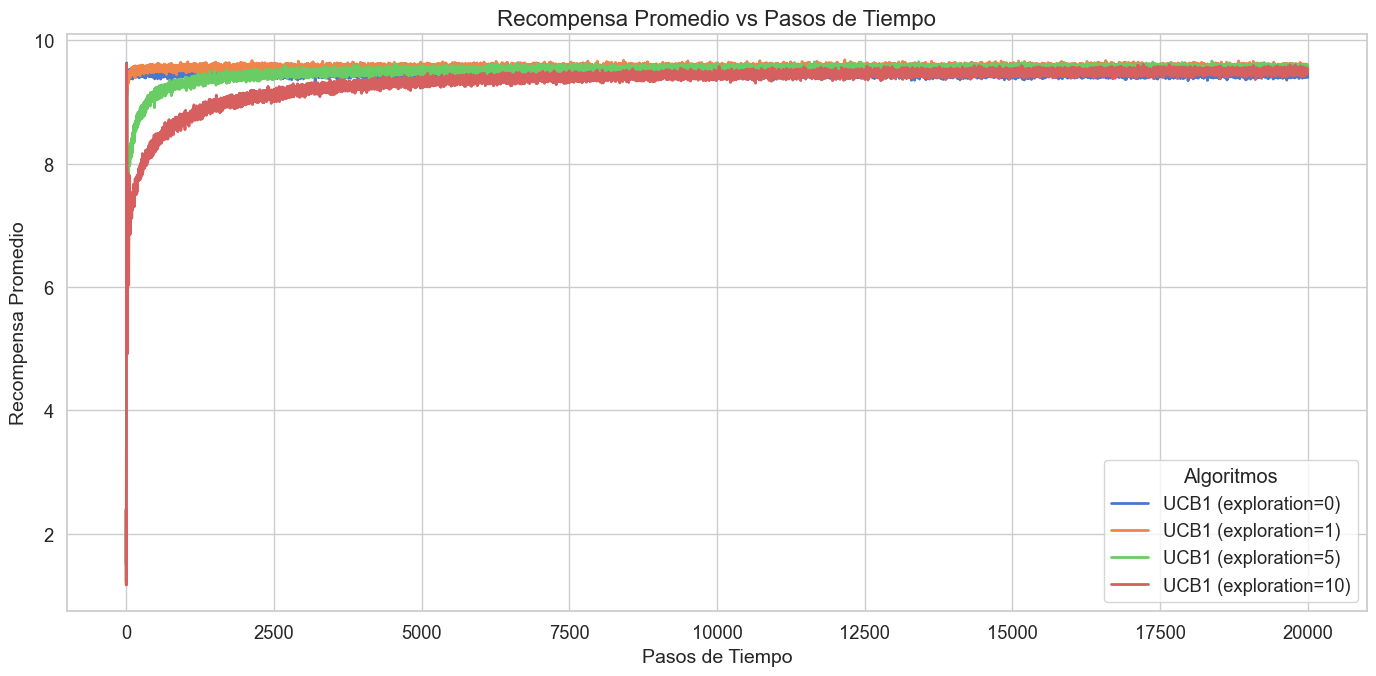

In [6]:
plot_average_rewards(STEPS, rewards_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Este gráfico de recompensas promedio comprobamos que en un número de pasos elevado todos los ajustes terminan con un valor muy similar y cercano al del brazo óptimo (9.56). Las configuraciones con más exploración tardan más pasos, pero las 4 terminan con resultados similares al largo plazo.

#### Selecciones óptimas

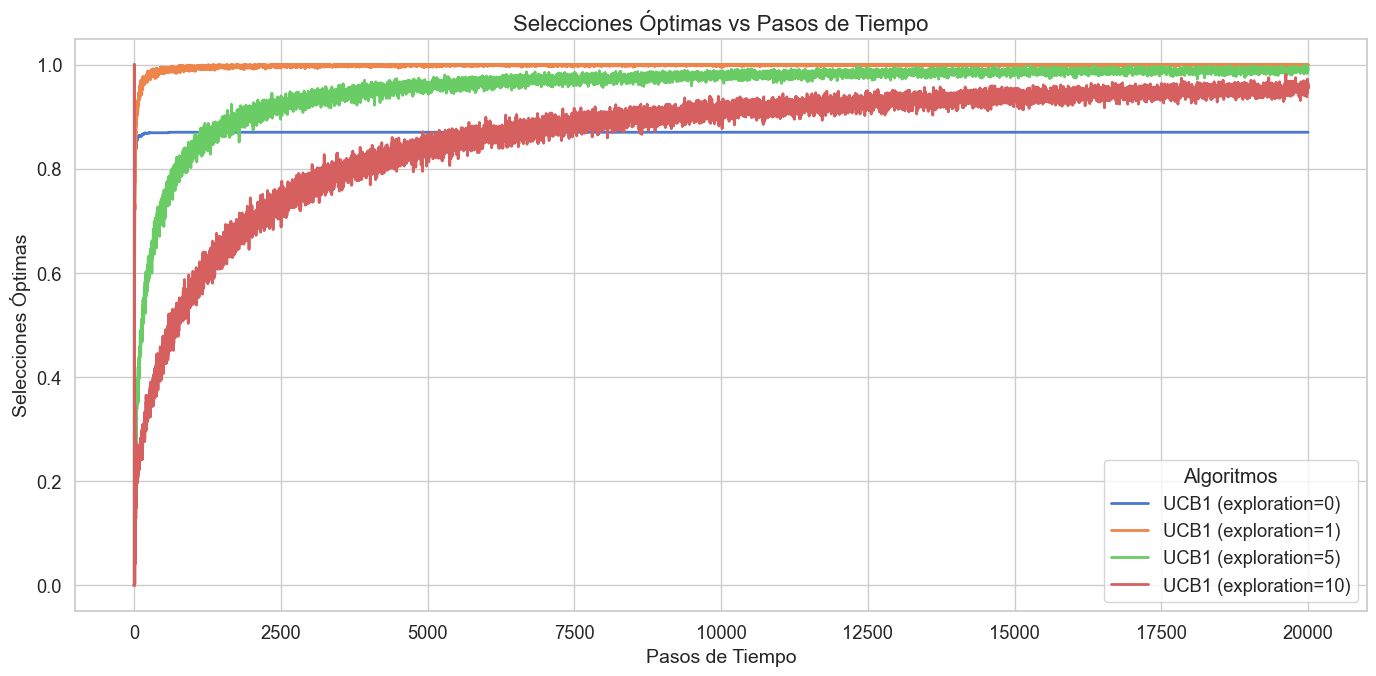

In [7]:
plot_optimal_selections(STEPS, optimal_selections_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Si lo miramos desde la perspectivas de las selecciones óptimas si se aprecia diferencia. El algoritmo sin exploración por su naturaleza no elegirá el brazo óptimo en todas las ejecuciones, por lo que se ve damnificado. El resto de versiones tienden a converger en el mismo punto lo que encaja con la premisa con la que se diferencia del algoritmo $\epsilon$-Greedy, cuanto más diferente exploradora haya entre brazos, menos posibilidades habrá de elegir otro.

#### Arrepentimiento

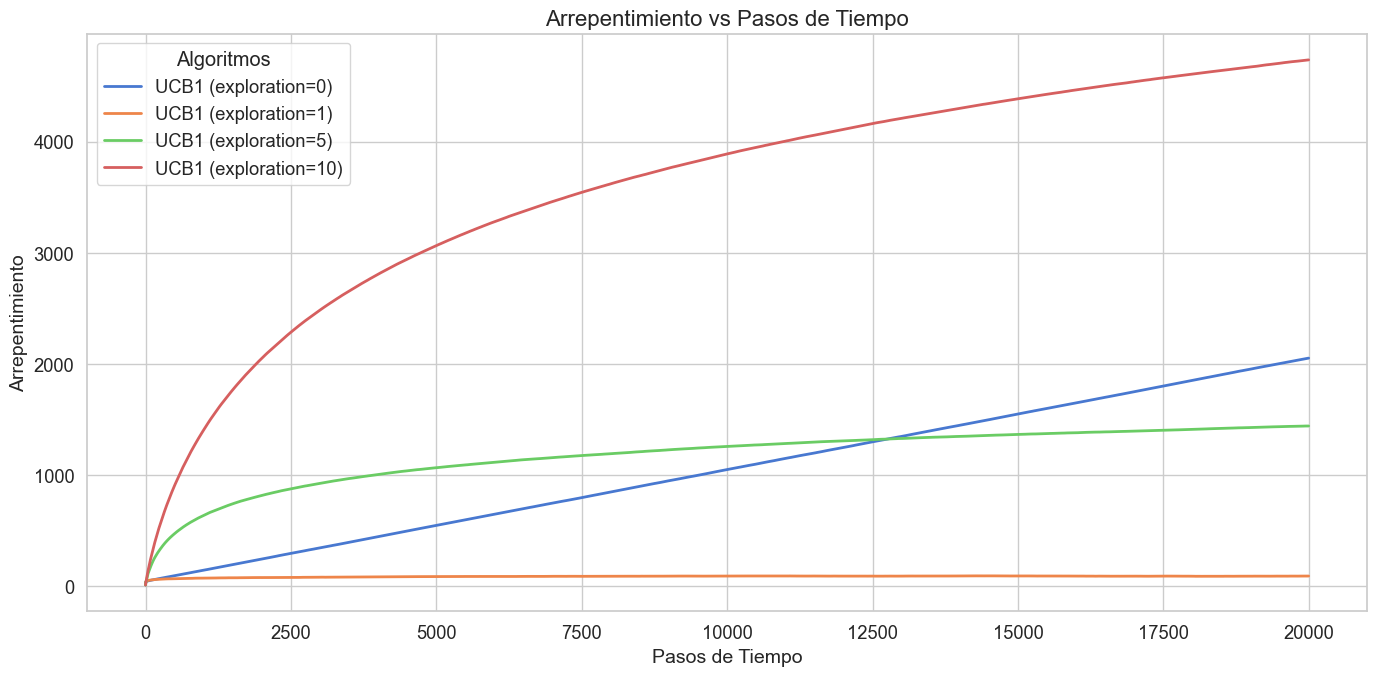

In [8]:
plot_regret(STEPS, regret_accumulated_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

El gráfico de arrepentimiento acumulado nos ayuda a decantarnos por la opción con exploration=1. Es capaz de llegar a los mismos resultados que las demás como hemos visto antes, pero para este caso reproducible lo hace acumulado el menor error durante todos los pasos de tiempo.

#### Estadísticas por brazo

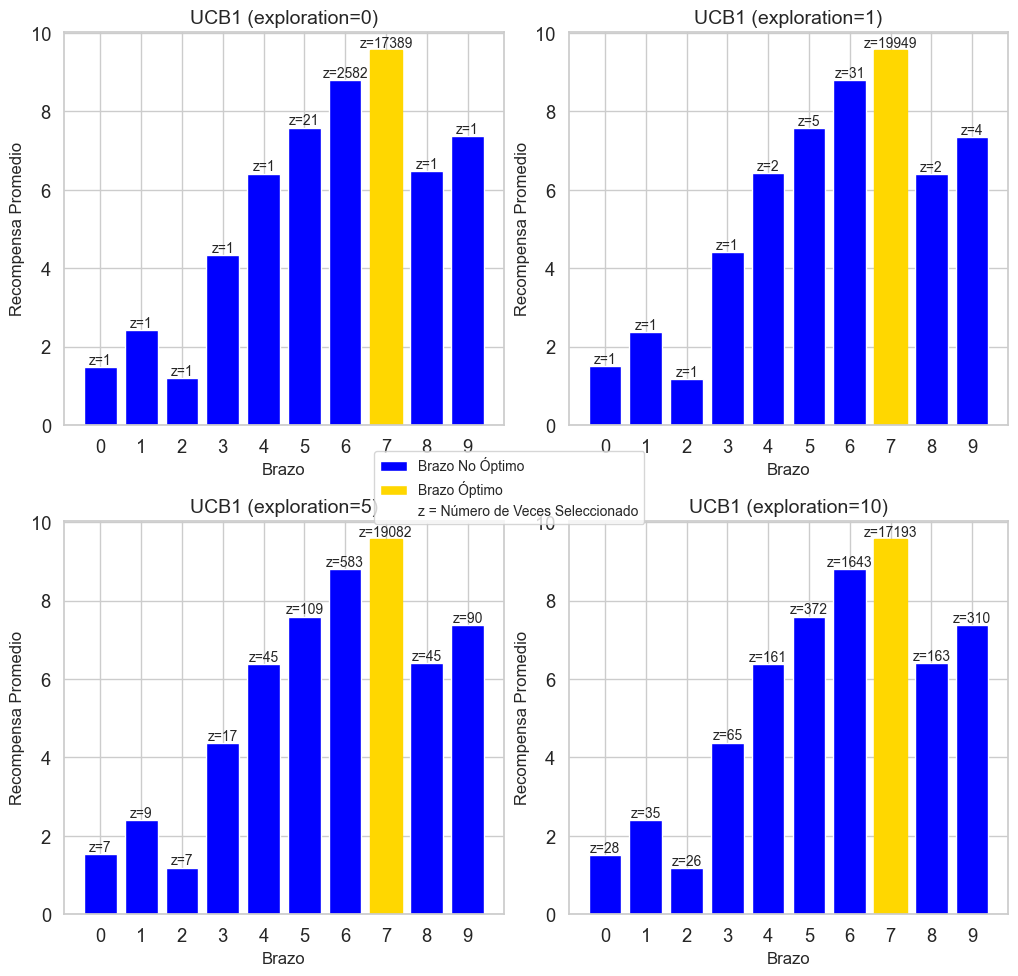

In [9]:
plot_arm_statistics(arm_stats_ucb1, algorithms_ucb1, SAVE_PLOTS_PATH)

Ver las estadísticas por brazo termina de confirmar lo visto hasta ahora. El algoritmo UCB1 funciona con diferentes valores de exploración, pero si se quiere minimizar el error en las primeras etapas de aprendizaje, un valor de exploración más bajo puede resultar en lo óptimo. Como es de esperar, no explorar en absoluto lleva a un estancamiento en soluciones subóptimas en muchas de las ejecuciones.

## Conclusiones

De este documento podemos concluir que el algoritmo UCB1 es eficaz en su propósito de maximizar la recompensa. A diferencia del algoritmo $\epsilon$-Greedy, cuanto más diferencia de recompensa promedio se obtenga entre brazos, con más probabilidad se elegirá el óptimo reduciendo así el arrepentimiento y aumentando el porcentaje de selecciones óptimas y las recompensas obtenidas.